## Download onto Google Colab

In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "1x8Kc4E15jwqtQ90OjMbBj2kSN_Q0Zsm7"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "moon.jpg", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1x8Kc4E15jwqtQ90OjMbBj2kSN_Q0Zsm7
To: /content/moon.jpg
100%|██████████| 135k/135k [00:00<00:00, 4.88MB/s]


'moon.jpg'

#LAB 5


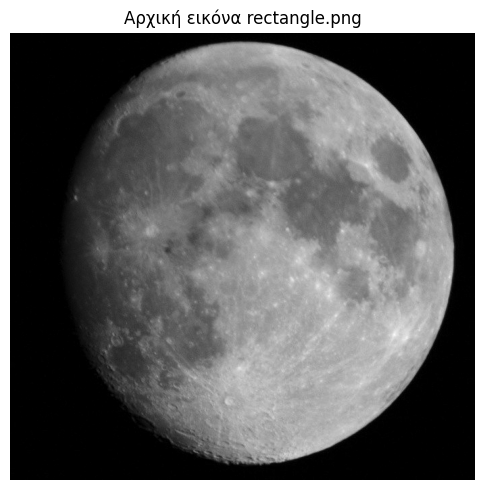

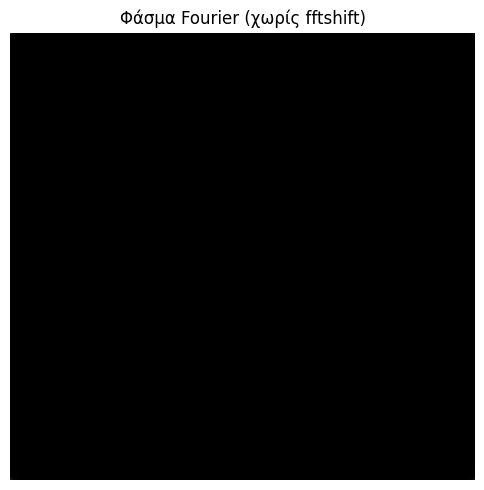

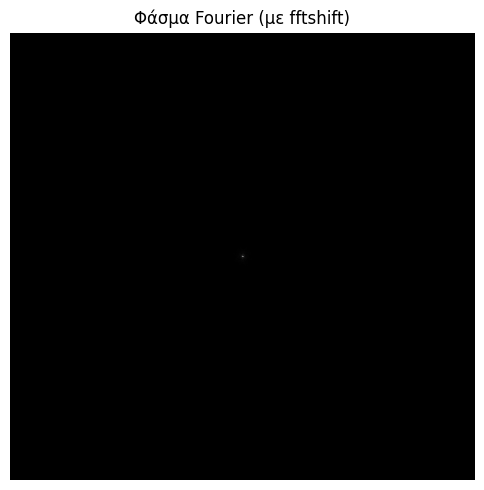

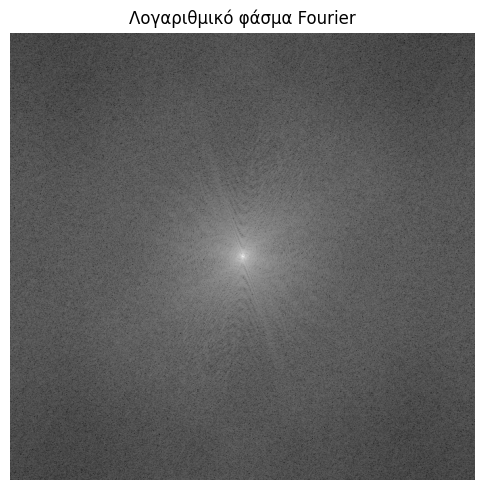

In [ ]:
# Εισαγωγή απαραίτητων βιβλιοθηκών
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Συνάρτηση για εμφάνιση εικόνων με matplotlib
def show_image(title, image, cmap='gray'):
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

#######################################
# Άσκηση 1: Fourier Transform - moon.jpg
#######################################
# Ανάγνωση εικόνας (σε grayscale)
img_rect = cv2.imread('moon.jpg', cv2.IMREAD_GRAYSCALE)
if img_rect is None:
    raise IOError("Η εικόνα rectangle.png δεν βρέθηκε.")

# Υπολογισμός Fourier μετασχηματισμού
F_rect = np.fft.fft2(img_rect)
# Χωρίς μετατόπιση: το μέτρο του Fourier
F_rect_abs = np.abs(F_rect)

# Μετατόπιση του μηδενικού συχνότητας στο κέντρο
F_rect_shift = np.fft.fftshift(F_rect)
F_rect_shift_abs = np.abs(F_rect_shift)

# Λογαριθμική απεικόνιση
F_rect_log = np.log(1 + F_rect_shift_abs)

# Εμφάνιση εικόνων
show_image('Αρχική εικόνα rectangle.png', img_rect)
show_image('Φάσμα Fourier (χωρίς fftshift)', F_rect_abs, cmap='gray')
show_image('Φάσμα Fourier (με fftshift)', F_rect_shift_abs, cmap='gray')
show_image('Λογαριθμικό φάσμα Fourier', F_rect_log, cmap='gray')


In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "10UXyMFm0X4KQxjM83x_Pc58rWfY2HAJV"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "circuit.tif", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10UXyMFm0X4KQxjM83x_Pc58rWfY2HAJV
To: /content/circuit.tif
100%|██████████| 76.8k/76.8k [00:00<00:00, 3.36MB/s]


'circuit.tif'

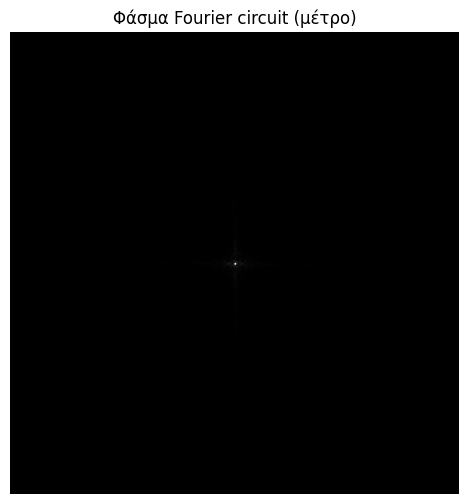

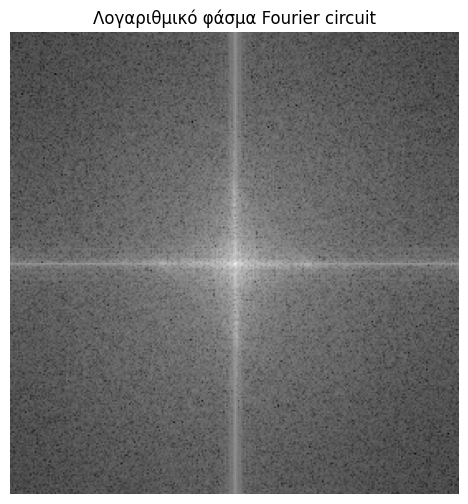

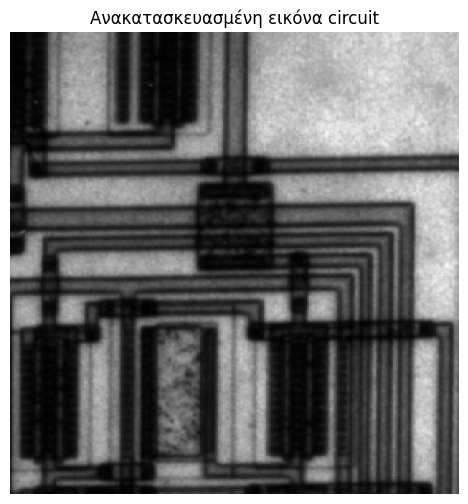

In [ ]:
# Εισαγωγή απαραίτητων βιβλιοθηκών
import cv2
import numpy as np
import matplotlib.pyplot as plt
#######################################
# Άσκηση 2: Fourier Transform - cameraman.tif και ανακατασκευή
#######################################
# Ανάγνωση εικόνας cameraman.tif
img_cam = cv2.imread('circuit.tif', cv2.IMREAD_GRAYSCALE)
if img_cam is None:
    raise IOError("Η εικόνα circuit δεν βρέθηκε.")

# Fourier μετασχηματισμός
F_cam = np.fft.fft2(img_cam)
F_cam_shift = np.fft.fftshift(F_cam)

# Μέτρο και λογαριθμικό φάσμα
F_cam_mag = np.abs(F_cam_shift)
F_cam_log = np.log(1 + F_cam_mag)

# Ανακατασκευή εικόνας μέσω του αντίστροφου μετασχηματισμού
img_cam_reconstructed = np.fft.ifft2(F_cam)
img_cam_reconstructed = np.abs(img_cam_reconstructed)

# Εμφάνιση αποτελεσμάτων
show_image('Φάσμα Fourier circuit (μέτρο)', F_cam_mag, cmap='gray')
show_image('Λογαριθμικό φάσμα Fourier circuit', F_cam_log, cmap='gray')
show_image('Ανακατασκευασμένη εικόνα circuit', img_cam_reconstructed, cmap='gray')


Ευρεση ακμών

76.25823266806722


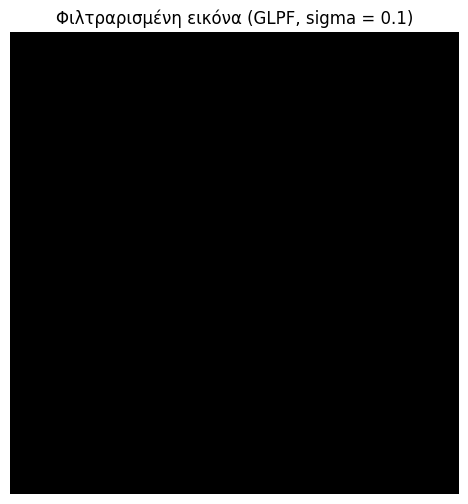

68.06622415222829


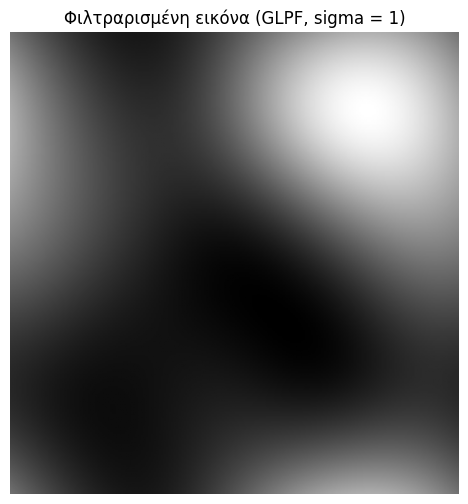

In [ ]:
#######################################
# Άσκηση 3: Gaussian Low Pass Filter (GLPF) στην cameraman.tif
#######################################
def gaussian_low_pass_filter(shape, sigma):
    M, N = shape
    # Δημιουργία πλέγματος συχνοτήτων
    u = np.arange(0, M)
    v = np.arange(0, N)
    u = u - M//2
    v = v - N//2
    V, U = np.meshgrid(v, u)
    D2 = U**2 + V**2
    H = np.exp(-D2/(2*(sigma**2)))
    return H

# Fourier μετασχηματισμός της εικόνας cameraman
F_cam = np.fft.fft2(img_cam)
F_cam_shift = np.fft.fftshift(F_cam)

# Λίστες τιμών σ
sigma_values = [0.1, 1]

for sigma in sigma_values:
    # Δημιουργία GLPF
    H = gaussian_low_pass_filter(img_cam.shape, sigma)
    # Εφαρμογή φίλτρου στο φάσμα
    F_filtered_shift = F_cam_shift * H
    # Αντίστροφος μετασχηματισμός (πρώτα μετατόπιση πίσω)
    F_filtered = np.fft.ifftshift(F_filtered_shift)
    img_filtered = np.fft.ifft2(F_filtered)
    img_filtered = np.abs(img_filtered)
    print(img_filtered[100,100])
    # Εμφάνιση αποτελέσματος για κάθε σ
    show_image(f'Φιλτραρισμένη εικόνα (GLPF, sigma = {sigma})', img_filtered, cmap='gray')


Υπολογισμός Gradient για Έγχρωμη Εικόνα lena.bmp

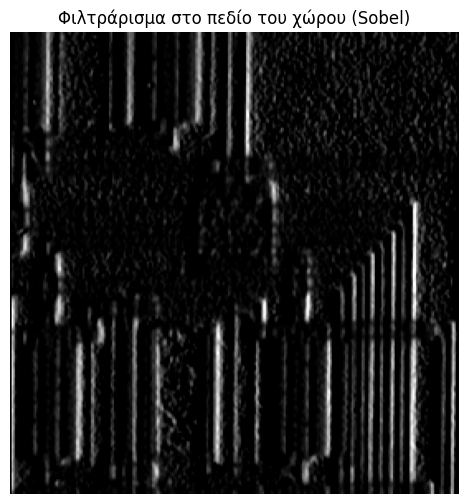

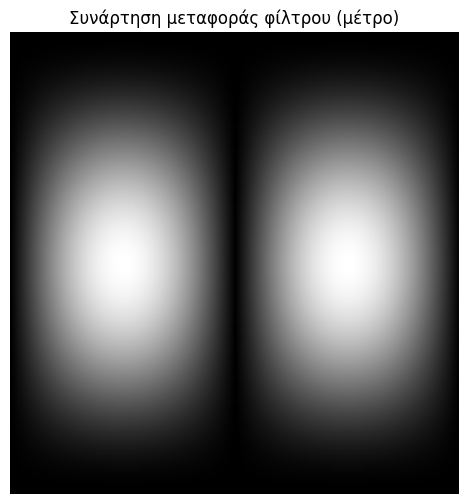

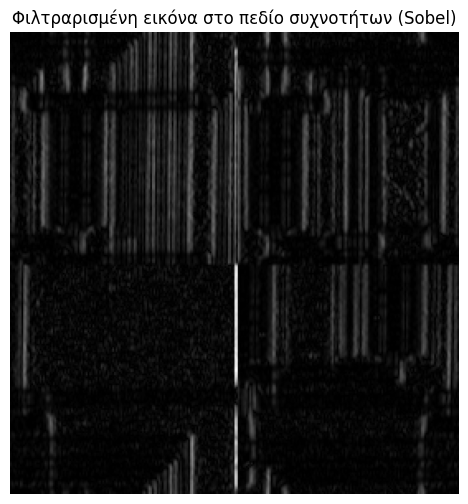

In [ ]:
#######################################
# Άσκηση 4: Φιλτράρισμα με Sobel – spatial και frequency domain - circuit.tif
#######################################
# Ανάγνωση εικόνας circuit.tif
img_circuit = cv2.imread('circuit.tif', cv2.IMREAD_GRAYSCALE)
if img_circuit is None:
    raise IOError("Η εικόνα circuit.tif δεν βρέθηκε.")

# Ορισμός φίλτρου Sobel για ανίχνευση ακμών κατά την x-διεύθυνση
sobel_kernel = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

# 1. Φιλτράρισμα στο πεδίο του χώρου
img_spatial = cv2.filter2D(img_circuit, -1, sobel_kernel)
show_image('Φιλτράρισμα στο πεδίο του χώρου (Sobel)', img_spatial, cmap='gray')

# 2. Φιλτράρισμα στο πεδίο των συχνοτήτων
# Υπολογισμός Fourier μετασχηματισμού της εικόνας
F_circuit = np.fft.fft2(img_circuit)
F_circuit_shift = np.fft.fftshift(F_circuit)

# Δημιουργία συνάρτησης μεταφοράς του φίλτρου
# Πρώτα, δημιουργούμε την αντίστοιχη συνάρτηση μεταφοράς του kernel:
# Πλάτωση (padding) του kernel στο μέγεθος της εικόνας
pad_kernel = np.zeros_like(img_circuit, dtype=np.float32)
kh, kw = sobel_kernel.shape
# Τοποθέτηση του kernel στο κέντρο
pad_kernel[:kh, :kw] = sobel_kernel
# Μετατόπιση ώστε το κέντρο του kernel να βρίσκεται στη θέση (0,0)
pad_kernel = np.fft.ifftshift(pad_kernel)
H_freq = np.fft.fft2(pad_kernel)

# Εφαρμογή φίλτρου στο φάσμα της εικόνας
F_filtered_freq = F_circuit * H_freq
img_freq_filtered = np.fft.ifft2(F_filtered_freq)
img_freq_filtered = np.abs(img_freq_filtered)

# Εμφάνιση αποτελεσμάτων
# Εμφάνιση της συνάρτησης μεταφοράς (μέτρο)
H_freq_shift = np.fft.fftshift(H_freq)
show_image('Συνάρτηση μεταφοράς φίλτρου (μέτρο)', np.abs(H_freq_shift), cmap='gray')
show_image('Φιλτραρισμένη εικόνα στο πεδίο συχνοτήτων (Sobel)', img_freq_filtered, cmap='gray')